In [13]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add the project root (where the nn/ folder lives) to the import path
sys.path.insert(0, os.path.abspath('..'))

# Now you can import from nn
from nn import network
from nn import mnist_loader

In [14]:
def darkness(img):
    """Return the mean pixel intensity of an image as a scalar."""
    return float(np.mean(img))

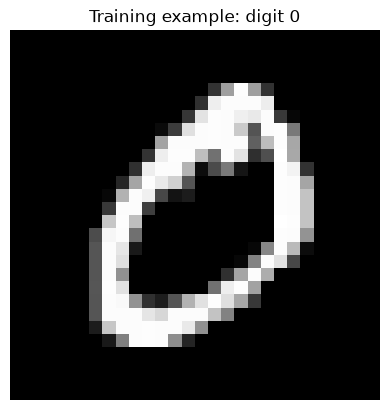

Training examples: 50,000; test examples: 10,000
Example mean pixel intensity: 0.1549


In [15]:
(training_data, validation_data, test_data) = mnist_loader.load_data_wrapper('../nn/mnist.pkl.gz')
training_data = list(training_data)
validation_data = list(validation_data)
test_data = list(test_data)

example_image, example_label = training_data[1]
plt.imshow(example_image.reshape(28, 28), cmap='gray')
plt.title(f"Training example: digit {int(np.argmax(example_label))}")
plt.axis('off')
plt.show()
print(f"Training examples: {len(training_data):,}; test examples: {len(test_data):,}")
print(f"Example mean pixel intensity: {darkness(example_image):.4f}")

In [16]:
class_darkness = np.zeros(10, dtype=float)
class_counts = np.zeros(10, dtype=int)

for image, label in training_data:
    digit = int(np.argmax(label))
    class_darkness[digit] += darkness(image)
    class_counts[digit] += 1

class_average_darkness = class_darkness / class_counts
correct = 0
for image, label in test_data:
    actual_digit = int(label)
    predicted_digit = int(np.argmin(np.abs(darkness(image) - class_average_darkness)))
    correct += predicted_digit == actual_digit

darkness_accuracy = correct / len(test_data)
print(f"Digit darkness test accuracy: {darkness_accuracy:.2%}")

Digit darkness test accuracy: 22.25%


## Accuracy comparison

Both neural networks train on the exact same seeded sample of 10,000 MNIST training images and are evaluated on all 10,000 test images after each of 30 epochs. Hyperparameters are the class defaults: 30 epochs, mini-batch size 10, and learning rate 3.0. The digit-darkness baseline uses the full training split; its accuracy is repeated for all 30 epochs.

Epoch 0 complete
Epoch 0 complete
Epoch 1/30: Network 1 = 76.35%, Network 2 = 77.48%
Epoch 0 complete
Epoch 0 complete
Epoch 2/30: Network 1 = 84.91%, Network 2 = 83.39%
Epoch 0 complete
Epoch 0 complete
Epoch 3/30: Network 1 = 86.60%, Network 2 = 85.95%
Epoch 0 complete
Epoch 0 complete
Epoch 4/30: Network 1 = 86.82%, Network 2 = 87.65%
Epoch 0 complete
Epoch 0 complete
Epoch 5/30: Network 1 = 88.54%, Network 2 = 86.61%
Epoch 0 complete
Epoch 0 complete
Epoch 6/30: Network 1 = 88.60%, Network 2 = 87.69%
Epoch 0 complete
Epoch 0 complete
Epoch 7/30: Network 1 = 88.87%, Network 2 = 89.14%
Epoch 0 complete
Epoch 0 complete
Epoch 8/30: Network 1 = 89.37%, Network 2 = 88.87%
Epoch 0 complete
Epoch 0 complete
Epoch 9/30: Network 1 = 89.48%, Network 2 = 88.91%
Epoch 0 complete
Epoch 0 complete
Epoch 10/30: Network 1 = 89.65%, Network 2 = 89.19%
Epoch 0 complete
Epoch 0 complete
Epoch 11/30: Network 1 = 89.67%, Network 2 = 89.11%
Epoch 0 complete
Epoch 0 complete
Epoch 12/30: Network 1 = 89.7

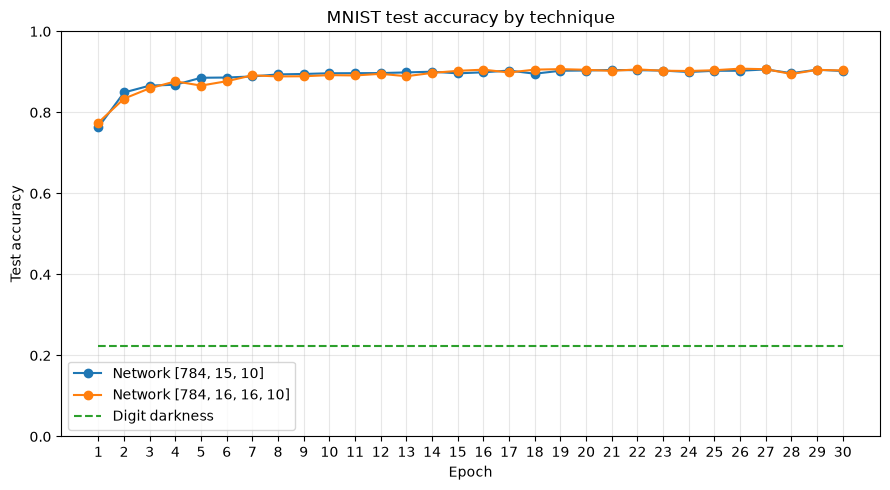

Digit darkness test accuracy: 22.25%


In [18]:
import random

EPOCHS = 30
MINI_BATCH_SIZE = 10
LEARNING_RATE = 3.0
TRAINING_SAMPLE_SIZE = 10_000

np.random.seed(42)
random.seed(42)
sample_indices = np.random.default_rng(42).choice(
    len(training_data), size=TRAINING_SAMPLE_SIZE, replace=False
)
shared_training_data = [training_data[index] for index in sample_indices]

network1_accuracies = []
network2_accuracies = []

network1 = network.Network([784, 15, 10])
network2 = network.Network([784, 16, 16, 10])

for epoch in range(1, EPOCHS + 1):
    network1.SGD(shared_training_data, 1, MINI_BATCH_SIZE, LEARNING_RATE)
    network1_accuracies.append(network1.evaluate(test_data) / len(test_data))

    network2.SGD(shared_training_data, 1, MINI_BATCH_SIZE, LEARNING_RATE)
    network2_accuracies.append(network2.evaluate(test_data) / len(test_data))

    print(
        f"Epoch {epoch}/{EPOCHS}: "
        f"Network 1 = {network1_accuracies[-1]:.2%}, "
        f"Network 2 = {network2_accuracies[-1]:.2%}"
    )

darkness_accuracies = [darkness_accuracy] * EPOCHS

epoch_numbers = range(1, EPOCHS + 1)
plt.figure(figsize=(9, 5))
plt.plot(epoch_numbers, network1_accuracies, marker="o", label="Network [784, 15, 10]")
plt.plot(epoch_numbers, network2_accuracies, marker="o", label="Network [784, 16, 16, 10]")
plt.plot(epoch_numbers, darkness_accuracies, linestyle="--", label="Digit darkness")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("MNIST test accuracy by technique")
plt.xticks(list(epoch_numbers))
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Digit darkness test accuracy: {darkness_accuracy:.2%}")